In [1]:
import numpy as np
from sklearn.model_selection import train_test_split

def load_and_clean(filename):
    return np.loadtxt(filename, skiprows=2)

data_x = load_and_clean('x24x24.txt')
data_y = load_and_clean('y24x24.txt')
data_z = load_and_clean('z24x24.txt')
full_data = np.vstack([data_x, data_y, data_z])

X = full_data[:, :576]
y = full_data[:, 578]


X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=67,
    stratify=y           # photos of a person will be in both sets
)

In [ ]:
unique_classes, counts = np.unique(y, return_counts=True)
class_counts = dict(zip(unique_classes.astype(int), counts))
class_counts

AttributeError: module 'numpy' has no attribute 'value_counts'

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

weak_learner = DecisionTreeClassifier(max_depth=1)
n_estimators = 200

adaboost_clf = AdaBoostClassifier(
    estimator=weak_learner,
    n_estimators=n_estimators,
    random_state=67,
).fit(X_train, y_train)


In [70]:
y_pred=adaboost_clf.predict(X_val)

In [71]:
y_pred

array([45., 34., 23., ..., 40.,  6., 15.], shape=(1367,))

In [72]:
correct_predictions = [y_val[i] == y_pred[i] for i in range(len(y_pred))]

accuracy = np.mean(correct_predictions)
accuracy

np.float64(0.1572787125091441)

In [73]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         0.0       0.25      0.06      0.10        31
         1.0       0.14      0.03      0.04        38
         2.0       0.00      0.00      0.00        26
         3.0       0.17      0.04      0.06        27
         4.0       0.20      0.10      0.13        20
         5.0       0.00      0.00      0.00        20
         6.0       0.08      0.17      0.11        40
         7.0       0.33      0.06      0.10        17
         8.0       0.16      0.59      0.25        37
         9.0       0.00      0.00      0.00        21
        10.0       0.22      0.16      0.19        25
        11.0       0.16      0.08      0.11        37
        12.0       0.12      0.03      0.05        31
        13.0       0.12      0.20      0.15        45
        14.0       1.00      0.04      0.08        23
        15.0       0.02      0.04      0.03        27
        16.0       0.00      0.00      0.00        15
        17.0       0.00    

c:\Users\marta\vs_projects\ai_project_photo_recognition_adaboost_ann\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marta\vs_projects\ai_project_photo_recognition_adaboost_ann\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marta\vs_projects\ai_project_photo_recognition_adaboost_ann\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_d

Text(0.5, 0, 'class name')

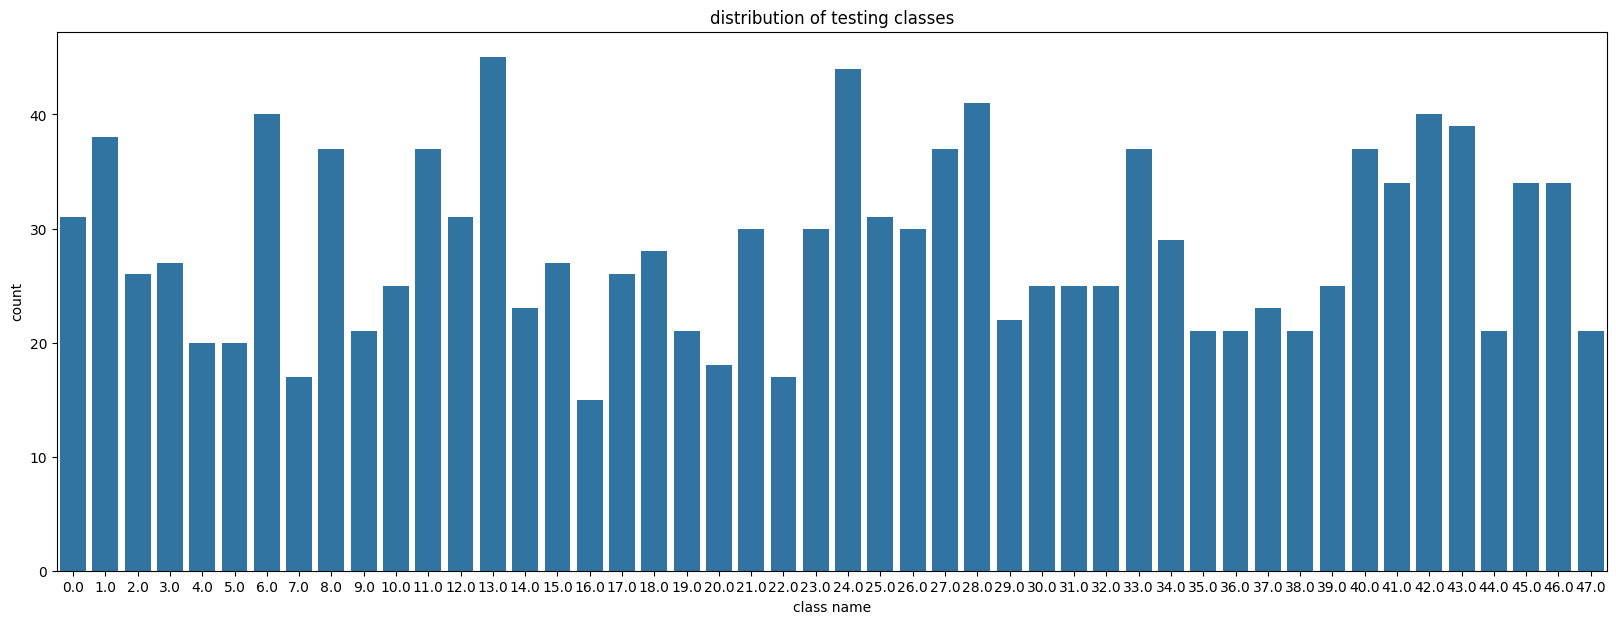

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,7))
sns.countplot(x=y_val)
plt.title("distribution of testing classes")
plt.xlabel('class name')

Text(0.5, 0, 'class name')

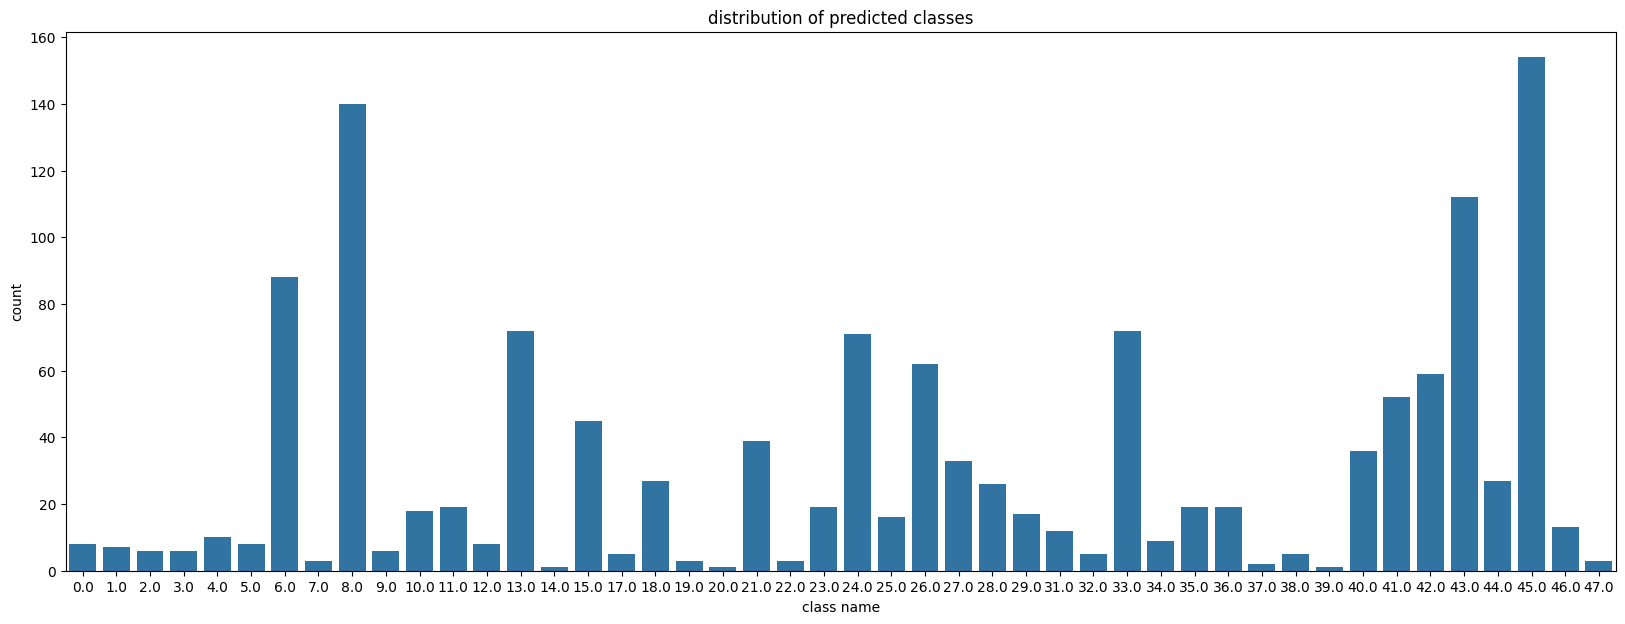

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,7))
sns.countplot(x=y_pred)
plt.title("distribution of predicted classes")
plt.xlabel('class name')